In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
import seaborn as sns
import re
import ipywidgets as widgets
import brainJ_output_analysis_v1 as bj
from glob import glob
from functools import reduce

# Mapping Anatomical Inputs/Outputs of All Dopaminergic neurons

In [2]:
data_type_options = ['Choose', 'Rabies_cells', 'Projections']
data_type = 'None'
drop_down = widgets.Dropdown(options = data_type_options, value='Choose', description='data_type:', disabled=False,) 
def dropdown_handler(change):
    global data_type
    print(change.new)
    data_type = change.new 
drop_down.observe(dropdown_handler, names='value')
display(drop_down)

Dropdown(description='data_type:', options=('Choose', 'Rabies_cells', 'Projections'), value='Choose')

In [3]:
data_dir = '/Users/Documents/...'

animal, atlas_type, inj_site = 'DAT_Cre_', 'ABA_CCF_updated', 'SNc'

if data_type == 'Rabies_cells':
    dir_type, channel = 'BrainJ_output_rabies_', 'C2_'
    cell_counts = 'Total_Cells'
    cell_counts_RL = [f'{cell_counts}_Right', f'{cell_counts}_Left']
    cell_threshold, edge_threshold, ylim_counts, ylim_prop = 100, 0.3, 6000, 6

elif data_type == 'Projections':
    dir_type, channel = 'BrainJ_output_proj_', 'C3_'
    density = 'Projection_Density'
    density_RL = [f'{density}_Right', f'{density}_Left']
    proj_threshold, ylim_prop = 2.0, 80

save_dir = os.path.join(data_dir + dir_type + atlas_type, 'output')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

Atlas_Regions = pd.read_csv(os.path.join(data_dir + atlas_type + '/Atlas_Regions_' + atlas_type + '.csv'))
ABA_fiber_tract = pd.read_csv(os.path.join(data_dir + atlas_type + '/ABA_fiber_tracts_VS_grv_' + atlas_type + '.csv'))

RL, RL_short, projection, average, figsize = ['Right', 'Left'], ['R', 'L'], ['Ipsilateral', 'Contralateral'], 'median', (20, 5)

col_df = Atlas_Regions.assign(
    hex_color=Atlas_Regions[['red', 'green', 'blue']].apply(lambda r: bj.rgb_to_hex(*r), axis=1)
)[['output_id', 'hex_color', 'acronym', 'name', 'graph_order']].copy()

col_df['graph_order_changed'] = col_df['graph_order'].replace(
    {
        1304: 1400, 1307: 1401, 1313: 1402, 1305: 1403,
        1308: 1404, 1310: 1405, 1312: 1406, 1306: 1407,
        1309: 1408, 1311: 1409, 1314: 1410
    }
)

In [4]:
if data_type == 'Rabies_cells':
    print('Please go ahead!')
elif data_type == 'Projections':
    filename_DAT = [fname for fname in os.listdir(os.path.join(data_dir + dir_type + atlas_type + '/data')) if fname.endswith(os.path.join(inj_site + '_' + channel + 'Measured_' + density + '.csv'))]
    filename_DAT = [fname for fname in filename_DAT if animal in fname]
    filename_DAT.sort()
    
    df_DAT_ipsi = bj.create_proj_df_for_figure_reorder_projections(data_dir, dir_type, atlas_type, filename_DAT, density_RL[0], ABA_fiber_tract, inj_site, col_df, proj_threshold)
    df_DAT_contra = bj.create_proj_df_for_figure_reorder_projections(data_dir, dir_type, atlas_type, filename_DAT, density_RL[1], ABA_fiber_tract, inj_site, col_df, proj_threshold)
    df_DAT_both, df_DAT_both_lf = bj.align_brain_region_projections(df_DAT_ipsi, df_DAT_contra, col_df, atlas_type)
      
    graphtype = 'Projections'
    cell_or_density = density  
    threshold = proj_threshold 
    ylim = ylim_prop
    bj.create_final_bar_graph(graphtype, save_dir, df_DAT_both, animal, projection, atlas_type, channel, inj_site, average, cell_or_density, threshold, ylim, figsize)

Please go ahead!


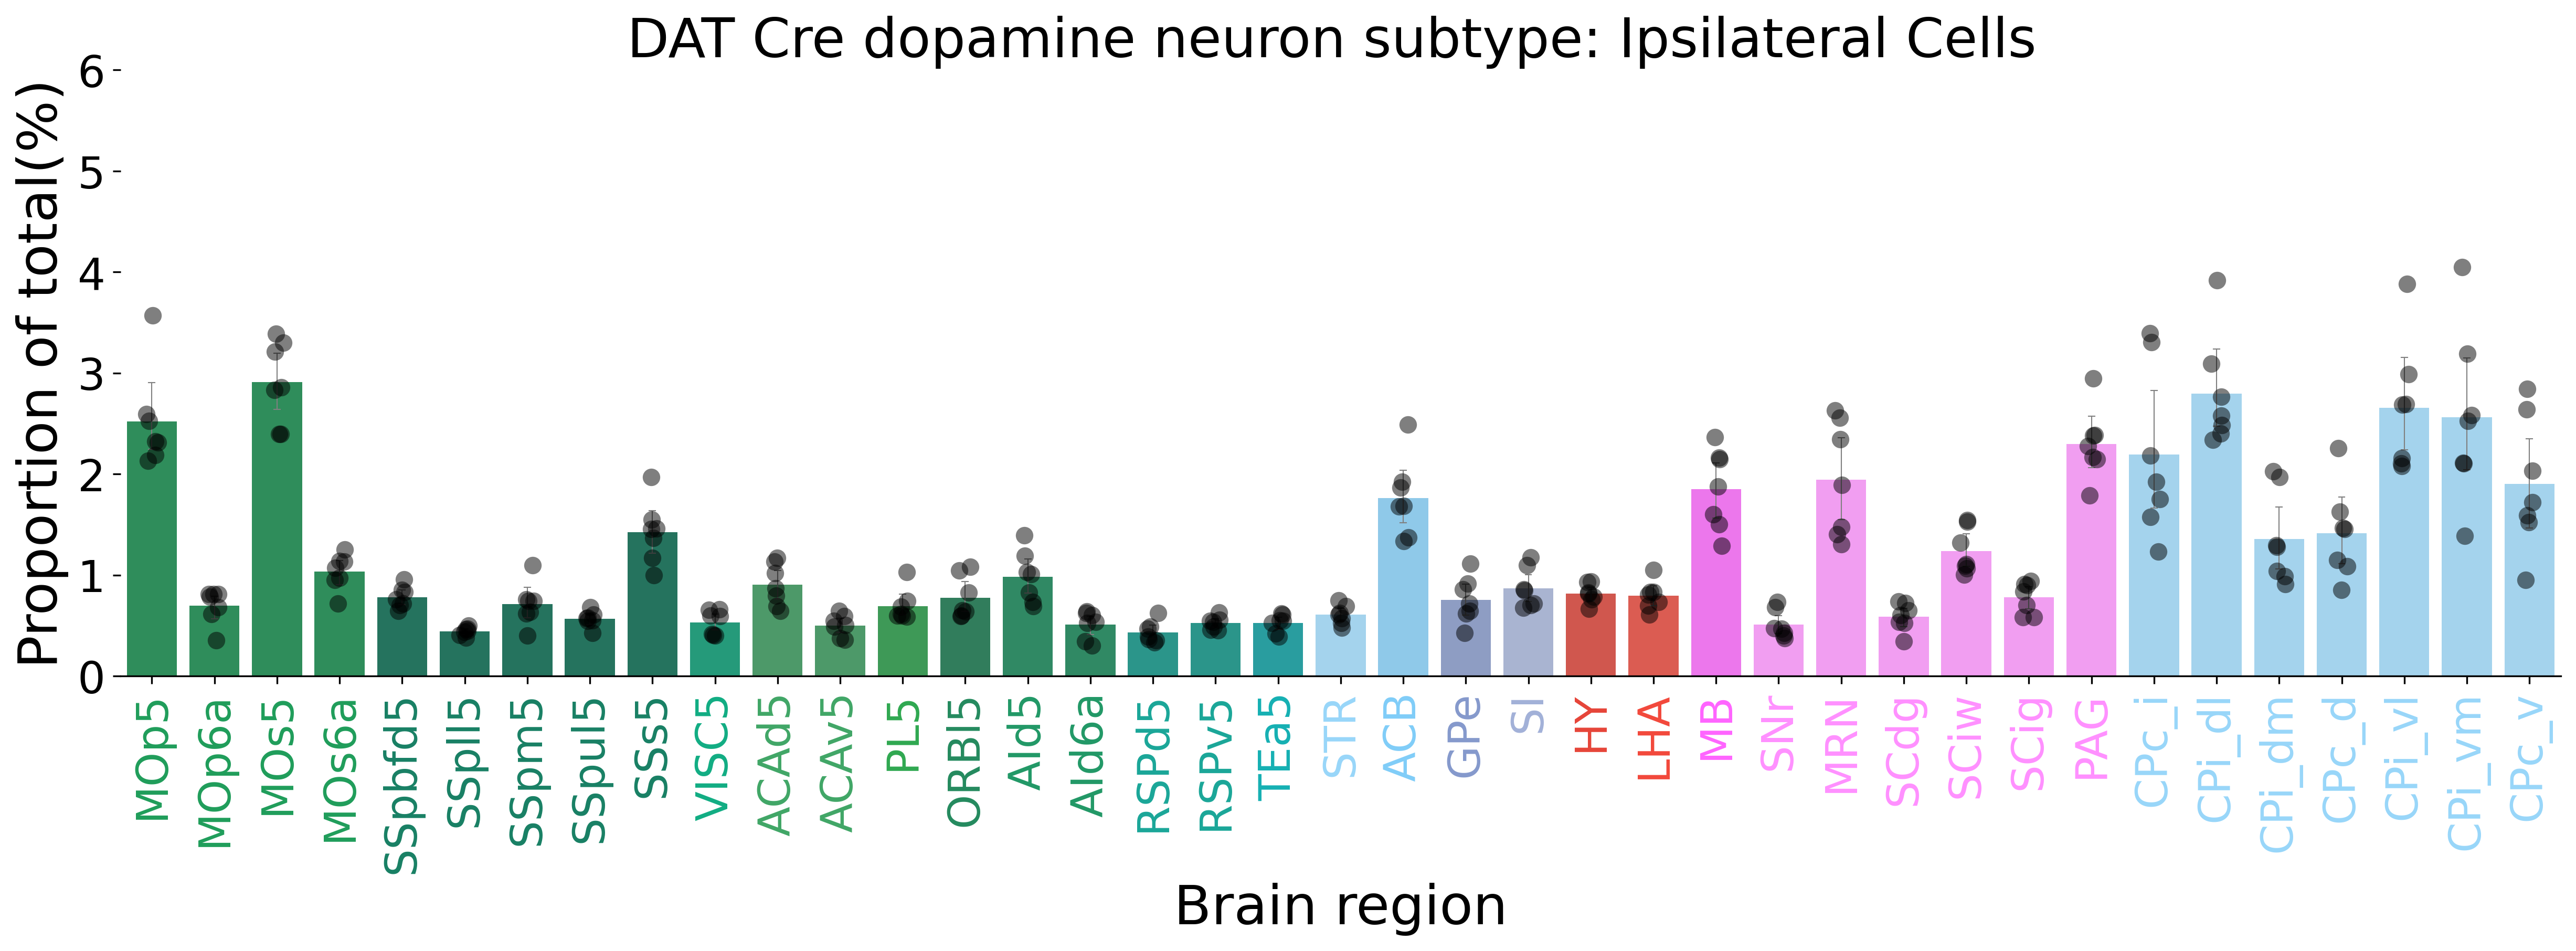

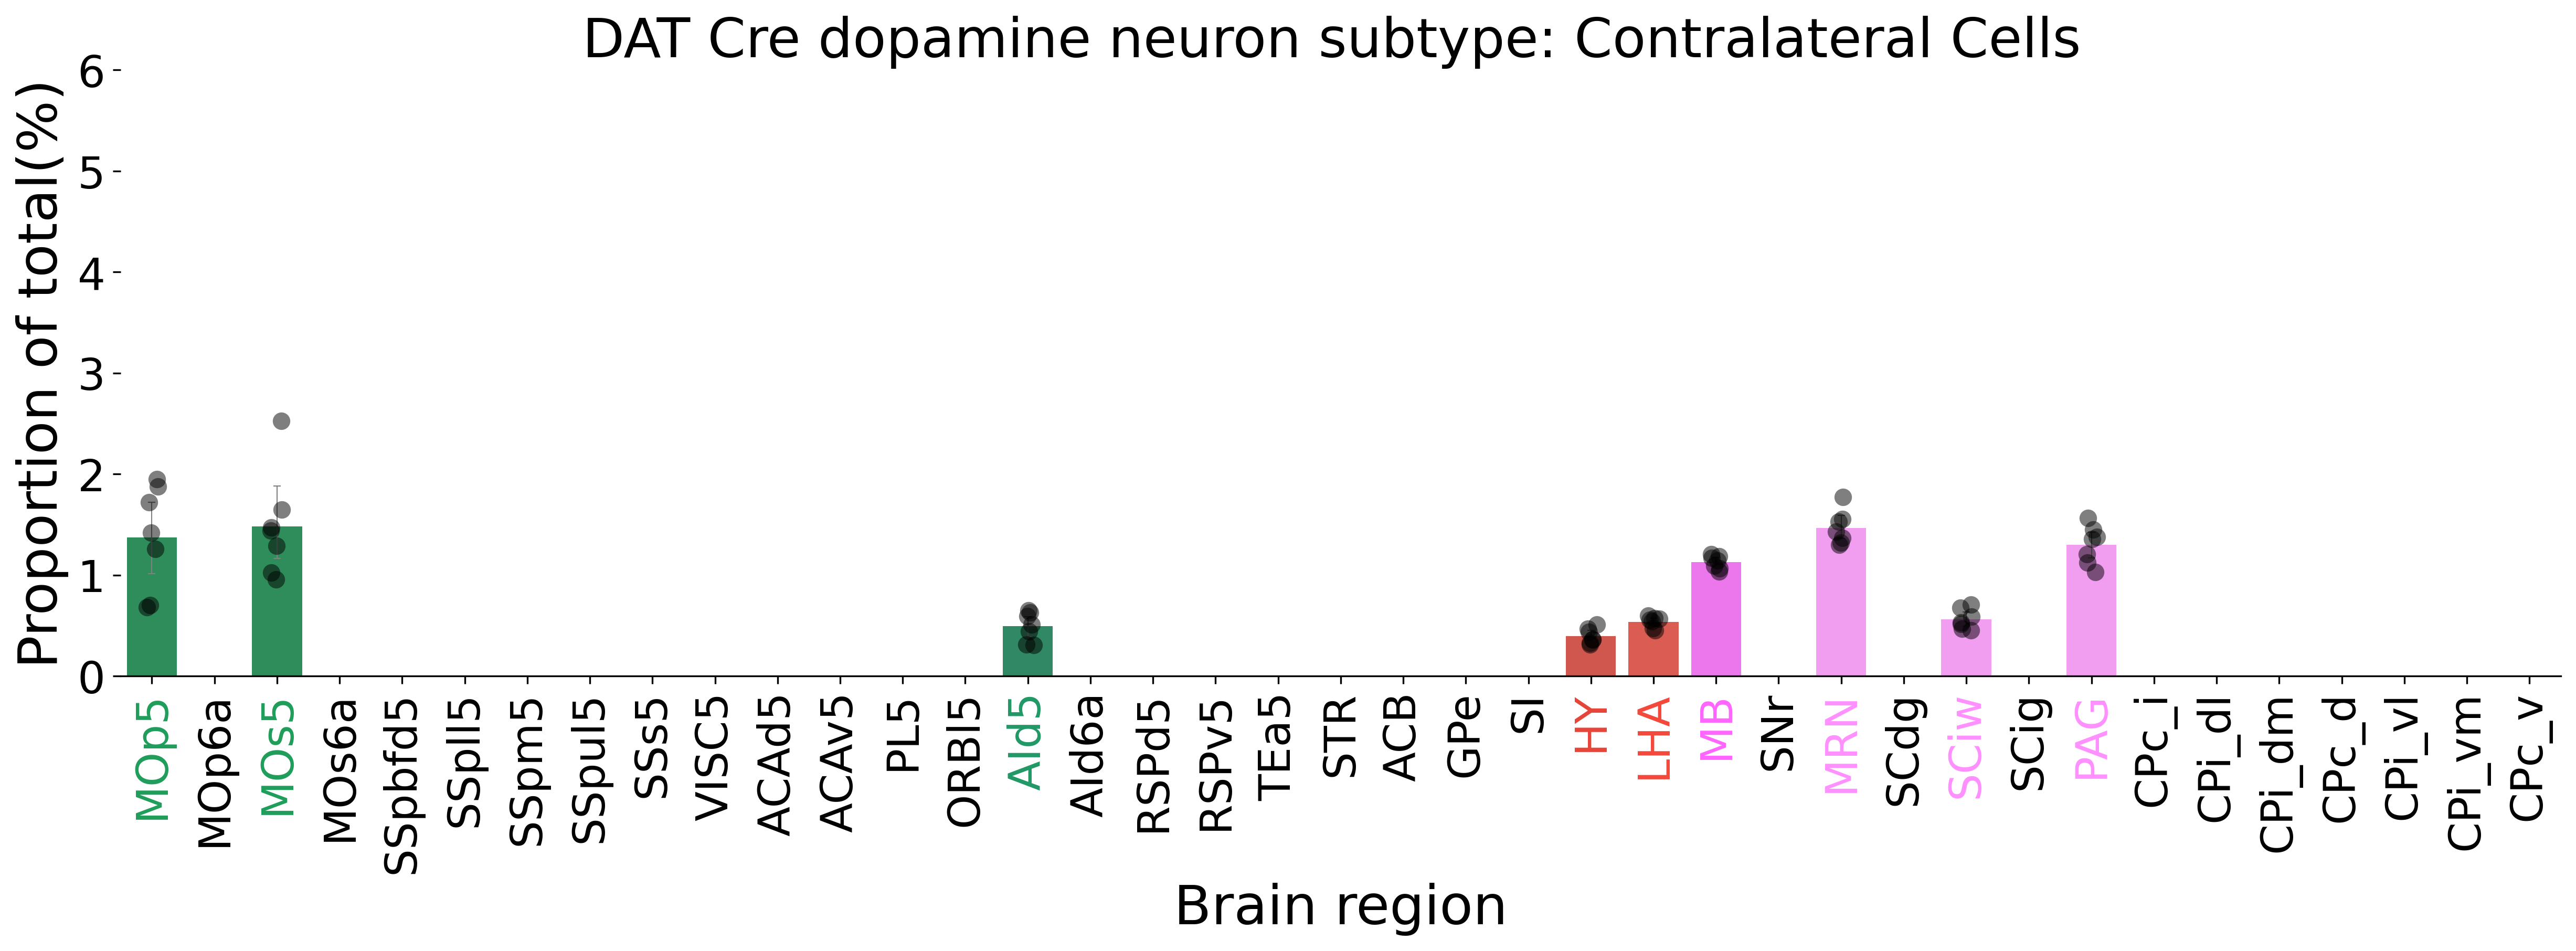

In [5]:
if data_type == 'Rabies_cells':
    filename_DAT = [fname for fname in os.listdir(os.path.join(data_dir + dir_type + atlas_type + '/data')) if fname.endswith(os.path.join(inj_site + '_' + channel + 'Detected_Cells_Summary' + '.csv'))]
    filename_DAT = [fname for fname in filename_DAT if animal in fname]
    filename_DAT.sort()
    
    graphtype = 'Cells_prop'
    df_DAT_ipsi_sum = bj.create_rabies_df_sum_reorder_cells(data_dir, dir_type, atlas_type, filename_DAT, cell_counts_RL[0], ABA_fiber_tract, inj_site, col_df)
    df_DAT_contra_sum = bj.create_rabies_df_sum_reorder_cells(data_dir, dir_type, atlas_type, filename_DAT, cell_counts_RL[1], ABA_fiber_tract, inj_site, col_df)
    df_DAT_ipsi_sum.loc['Total'] = df_DAT_ipsi_sum.loc['Sum_one_side'] + df_DAT_contra_sum.loc['Sum_one_side'] 
    df_DAT_contra_sum.loc['Total'] = df_DAT_ipsi_sum.loc['Sum_one_side'] + df_DAT_contra_sum.loc['Sum_one_side']
    filter_col, df_DAT_ipsi_sum_prop = bj.create_rabies_df_for_figure_prop_cells(df_DAT_ipsi_sum, cell_counts_RL[0],col_df,edge_threshold)
    filter_col, df_DAT_contra_sum_prop = bj.create_rabies_df_for_figure_prop_cells(df_DAT_contra_sum, cell_counts_RL[1],col_df,edge_threshold)
    df_DAT_ratio_both, df_DAT_ratio_both_lf = bj.align_brain_region_cells(df_DAT_ipsi_sum_prop, df_DAT_contra_sum_prop, col_df, atlas_type)
    
    cell_or_density = cell_counts 
    threshold = cell_threshold    
    ylim = ylim_prop
    bj.create_final_bar_graph(graphtype, save_dir, df_DAT_ratio_both, animal, projection, atlas_type, channel, inj_site, average, cell_or_density, threshold, ylim, figsize)
else:
    print('Please go ahead!')

# Mapping Anatomical Inputs/Outputs of Dopaminergic neuron subtypes

In [6]:
if data_type == 'Rabies_cells':
    df_DAT_ipsi = bj.create_rabies_df_for_figure_reorder_cells(data_dir, dir_type, atlas_type, filename_DAT, cell_counts_RL[0], ABA_fiber_tract, inj_site, col_df, cell_threshold)
    df_DAT_contra = bj.create_rabies_df_for_figure_reorder_cells(data_dir, dir_type, atlas_type, filename_DAT, cell_counts_RL[1], ABA_fiber_tract, inj_site, col_df, cell_threshold)
    df_DAT_both, df_DAT_both_lf = bj.align_brain_region_cells(df_DAT_ipsi, df_DAT_contra, col_df, atlas_type)
    DAT_acronym = pd.merge(df_DAT_ipsi['acronym'], df_DAT_contra['acronym'], how='outer', on=['acronym', 'acronym']) 
    DAT_acronym_prop = pd.merge(df_DAT_ipsi_sum_prop['acronym'], df_DAT_contra_sum_prop['acronym'], how='outer', on=['acronym', 'acronym'])
else:
    DAT_acronym = pd.merge(df_DAT_ipsi['acronym'], df_DAT_contra['acronym'], how='outer', on=['acronym', 'acronym']) 

animal_options = ['Choose', 'Anxa1_', 'Calb1_', 'Vglut2_'] 
animal = 'None'
drop_down = widgets.Dropdown(options = animal_options, value='Choose', description='animal:', disabled=False,) 
def dropdown_handler(change):
    global animal
    print(change.new)
    animal = change.new 
drop_down.observe(dropdown_handler, names='value')
display(drop_down)

Dropdown(description='animal:', options=('Choose', 'Anxa1_', 'Calb1_', 'Vglut2_'), value='Choose')

In [7]:
data_path = os.path.join(data_dir + dir_type + atlas_type, 'data')

if data_type == 'Rabies_cells':
    print('Please go ahead!')
elif data_type == 'Projections':
    suffix = f'{inj_site}_{channel}Measured_{density}.csv'
    filename_Sub = sorted(f for f in os.listdir(data_path) if f.endswith(suffix) and animal in f)

    df_Sub_ipsi = bj.create_proj_df_for_figure_reorder_projections(data_dir, dir_type, atlas_type, filename_Sub, density_RL[0], ABA_fiber_tract, inj_site, col_df, proj_threshold)
    df_Sub_contra = bj.create_proj_df_for_figure_reorder_projections(data_dir, dir_type, atlas_type, filename_Sub, density_RL[1], ABA_fiber_tract, inj_site, col_df, proj_threshold)

    df_Sub_ipsi_selected = pd.merge(df_Sub_ipsi, DAT_acronym, how='right', on='acronym')
    df_Sub_contra_selected = pd.merge(df_Sub_contra, DAT_acronym, how='right', on='acronym')

    df_Sub_both, df_Sub_both_lf = bj.align_brain_region_projections(df_Sub_ipsi_selected, df_Sub_contra_selected, col_df, atlas_type)

    bj.create_final_bar_graph('Projections', save_dir, df_Sub_both, animal, projection, atlas_type, channel, inj_site, average, density, proj_threshold, ylim_prop, figsize)

Please go ahead!


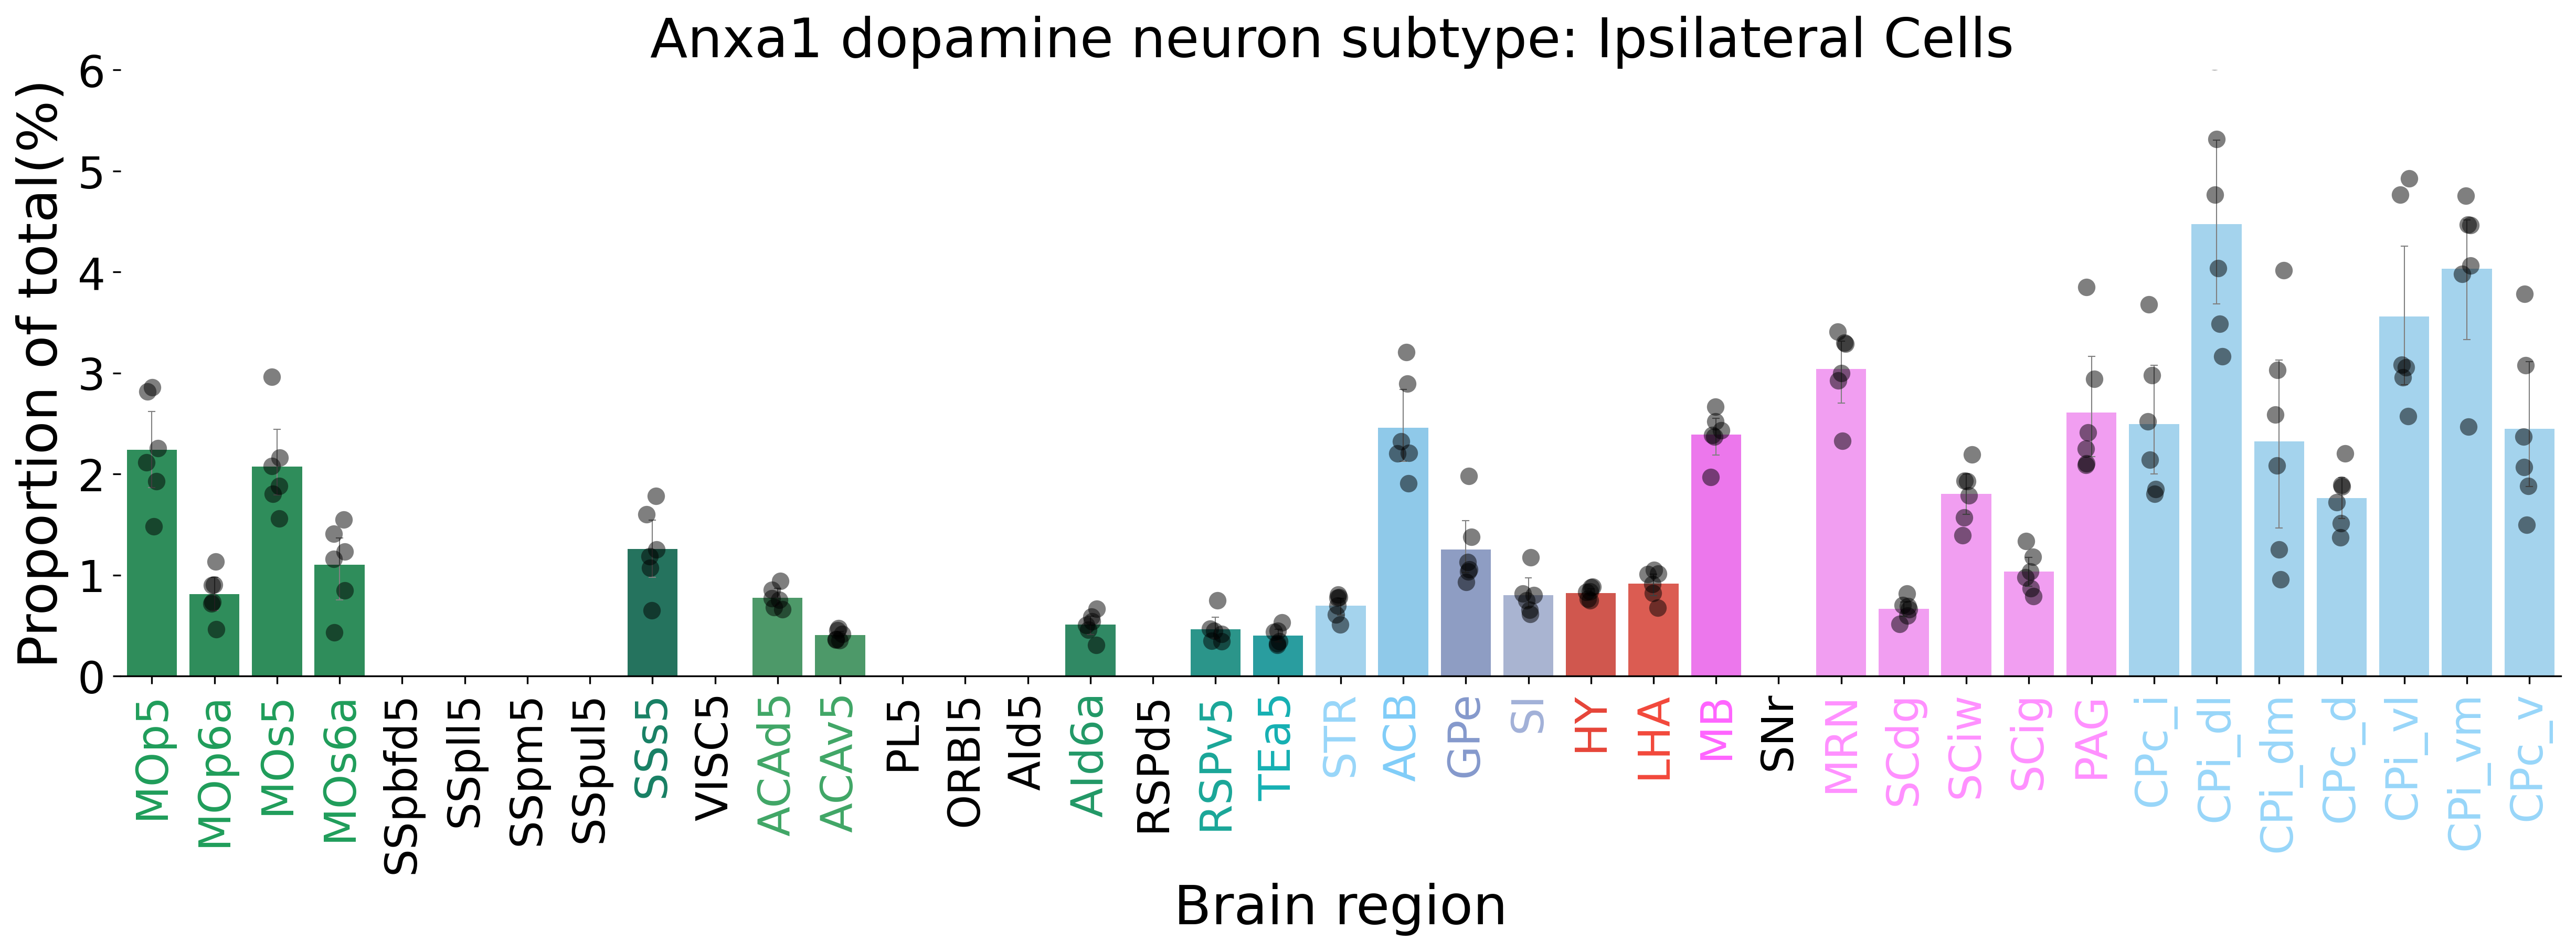

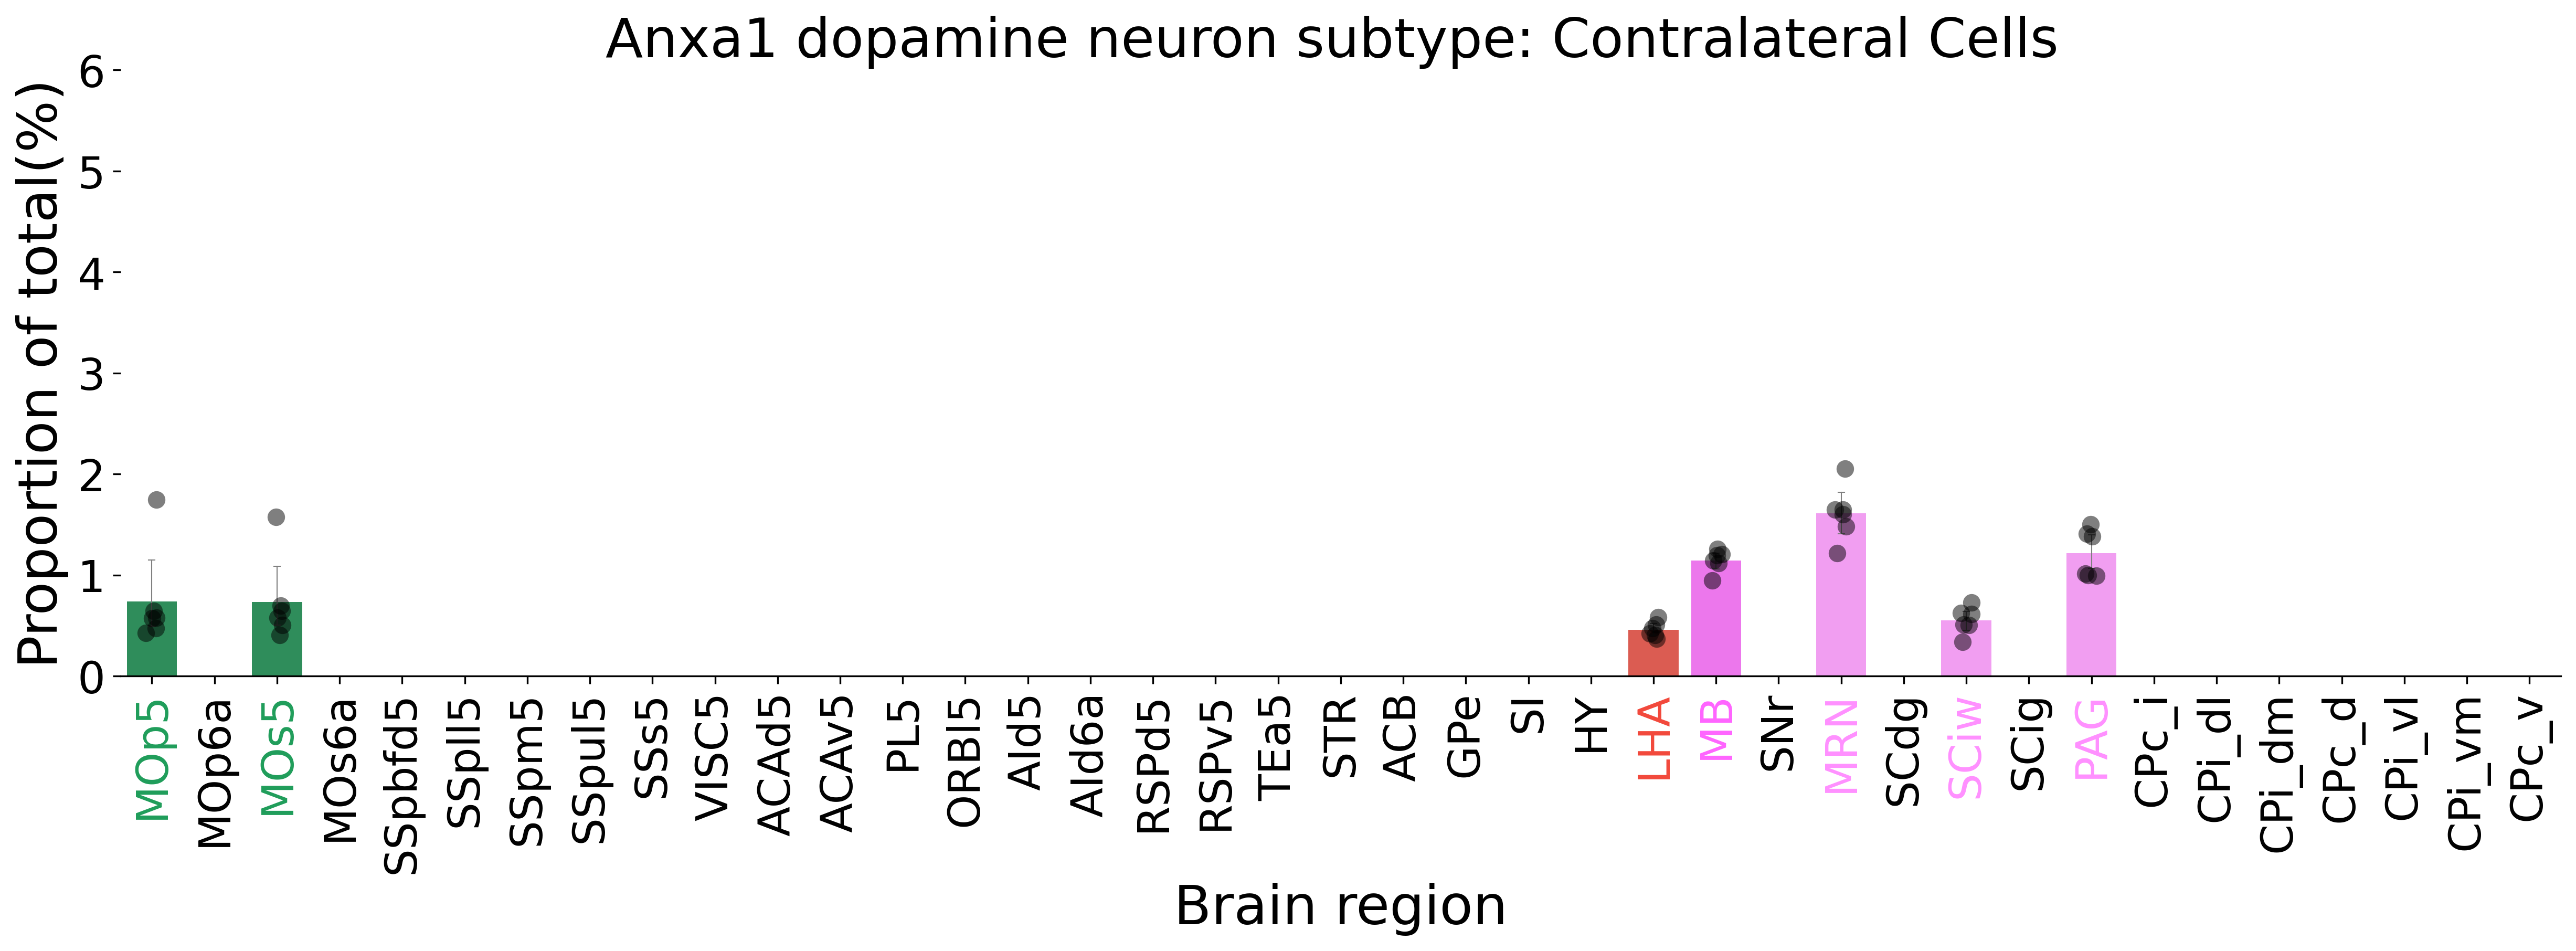

In [8]:
if data_type == 'Rabies_cells':    
    suffix = f'{inj_site}_{channel}Detected_Cells_Summary.csv'
    filename_Sub = sorted(f for f in os.listdir(data_path) if f.endswith(suffix) and animal in f)

    graphtype = 'Cells_prop'

    df_Sub_ipsi = bj.create_rabies_df_sum_reorder_cells(data_dir, dir_type, atlas_type, filename_Sub, cell_counts_RL[0], ABA_fiber_tract, inj_site, col_df)
    df_Sub_contra = bj.create_rabies_df_sum_reorder_cells(data_dir, dir_type, atlas_type, filename_Sub, cell_counts_RL[1], ABA_fiber_tract, inj_site, col_df)

    total = df_Sub_ipsi.loc['Sum_one_side'] + df_Sub_contra.loc['Sum_one_side']
    df_Sub_ipsi.loc['Total'] = total
    df_Sub_contra.loc['Total'] = total

    filter_col_ipsi, df_Sub_ipsi_prop = bj.create_rabies_df_for_figure_prop_cells(df_Sub_ipsi, cell_counts_RL[0], col_df, edge_threshold)
    filter_col_contra, df_Sub_contra_prop = bj.create_rabies_df_for_figure_prop_cells(df_Sub_contra, cell_counts_RL[1], col_df, edge_threshold)

    df_Sub_ipsi_prop_selected = pd.merge(df_Sub_ipsi_prop, DAT_acronym_prop, how='right', on='acronym')
    df_Sub_contra_prop_selected = pd.merge(df_Sub_contra_prop, DAT_acronym_prop, how='right', on='acronym')

    df_Sub_ratio_both, df_Sub_ratio_both_lf = bj.align_brain_region_cells(df_Sub_ipsi_prop_selected, df_Sub_contra_prop_selected, col_df, atlas_type)

    bj.create_final_bar_graph('Cells_prop', save_dir, df_Sub_ratio_both, animal, projection, atlas_type, channel, inj_site, average, cell_counts, cell_threshold, ylim_prop, figsize)
else:
    print('No more!')